⚪ Function F7 — Week 12 | Black-Box Optimisation
### Mike Kennelly | BBO Capstone Project | Final Query

---

## 📌 F7 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 6D |
| **Search space** | [0, 1]^6 |
| **Week** | 12 — FINAL QUERY |
| **All-time best (ATB)** | 2.8501 (Week 11) |
| **W11 result** | 2.8501 — NEW ATB ✓ (6th consecutive) |
| **Objective** | MAXIMISE ⬆️ |

---

## 🗓️ W12 Decision

**W12 strategy:** GP PIPELINE — trending cluster, continue directional gradient

**TuRBO direction:** SHRINK — strong gradient confirmed, trust GP EI

---

## 📊 Module 22 Clustering Analysis — W12 Justification

| Property | Value |
|----------|-------|
| **Cluster type** | ★ TRENDING CLUSTER (Module 22 secondary showcase) |
| **Cluster detail** | W6→W11: 2.119→2.413→2.598→2.597→2.720→2.850. Step sizes [0.061, 0.049, 0.001, 0.042, 0.061]. Intra-cluster spread=0.066 (tight — genuine gradient signal). Direction: X1 rising (+0.041 W10→W11), X6 rising (+0.001), X2-X5 declining. DYNAMIC cluster (centroid moving) -- dynamic cluster vs static attractor vs static attractor — this is WHY GP is trusted for F7 and overridden for all others. |
| **W12 rationale** | 6 consecutive improvements W6→W11. Trending cluster confirms genuine landscape ridge — GP gradient signal is trustworthy. Unlike static attractors (F2/F4/F6) where override is correct, a directional cluster warrants GP extrapolation. Run GP on W12 npy. If mu > 2.8501 → submit GP EI. If not → submit W11 ATB fallback. |

---

## 🗺️ Pipeline Overview

```
S0  Config & hyperparameters
S1  Imports
S2  Load data (f7_w12_inputs.npy / f7_w12_outputs.npy)
S3  Historical performance visualisation
S4  Binary labels (top 30%)
S5  CV model comparison (8 classifiers incl. CNN-1D)
S5B CNN inspection (Module 17 learning exercise)
S8  Generate & filter candidates
S9  Gaussian Process regression (Matérn 5/2)
S10 Acquisition functions (EI + UCB)
S11 Per-dimension sensitivity curves
S12 GP acquisition surfaces
S13 Submission dashboard
S14 Final formatted submission (GP PIPELINE — check output before submitting)
S15 Save hyperparameter record
```


In [1]:
FUNCTION_ID  = 'F7'
WEEK         = 12
INPUT_FILE   = 'f7_w12_inputs.npy'
OUTPUT_FILE  = 'f7_w12_outputs.npy'

# -- W12 Hyperparameters --------------------------------------
TOP_PERCENTILE    = 30
N_CANDIDATES      = 10000
EXPLOIT_RATIO     = 0.92
EXPLOIT_SIGMA     = 0.015
UCB_KAPPA         = 2.0
EI_XI             = 0.01
GP_RESTARTS       = 10
FILTER_PERCENTILE = 50
RANDOM_SEED       = 42
MAXIMIZE          = True

# Anisotropic sigma (per-dimension from W11 Ollama consensus)
ANISO_SIGMA = [0.015, 0.012, 0.012, 0.012, 0.012, 0.015]

NN_SMALL  = (16, 8)
NN_MEDIUM = (64, 32)
NN_LARGE  = (128, 64, 32)

# -- ATB override ---------------------------------------------
ATB_OVERRIDE_STR = '0.165978-0.338682-0.444076-0.255770-0.300940-0.704355'
ATB_COORDS       = [float(x) for x in ATB_OVERRIDE_STR.split('-')]

print(f'{FUNCTION_ID} Week {WEEK} -- FINAL QUERY')
print(f'Strategy : GP PIPELINE -- trending cluster, continue directional gradient')
print(f'ATB      : 2.8501  (Week 11)')
print(f'Override : {ATB_OVERRIDE_STR}')

F7 Week 12 -- FINAL QUERY
Strategy : GP PIPELINE -- trending cluster, continue directional gradient
ATB      : 2.8501  (Week 11)
Override : 0.165978-0.338682-0.444076-0.255770-0.300940-0.704355


---
## 📦 STEP 1 — Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm
import torch, torch.nn as nn, torch.optim as optim_torch
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(RANDOM_SEED)
print(f"[OK] Imports loaded -- {FUNCTION_ID} Week {WEEK}")

[OK] Imports loaded -- F7 Week 12


In [3]:
class TinyCNNClassifier(BaseEstimator, ClassifierMixin):
    """Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1) -- Module 17 learning exercise."""
    def __init__(self, n_epochs=200, lr=0.01, seed=42):
        self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
    def fit(self, X, y):
        torch.manual_seed(self.seed)
        n_feat=X.shape[1]; self.classes_=np.unique(y)
        class _CNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv=nn.Conv1d(1,8,kernel_size=min(2,n_feat),padding=0)
                self.relu=nn.ReLU(); self.drop=nn.Dropout(0.3)
                conv_out=8*max(1,n_feat-min(2,n_feat)+1)
                self.fc=nn.Linear(conv_out,1)
            def forward(self,x):
                x=self.relu(self.conv(x)); x=self.drop(x.view(x.size(0),-1))
                return self.fc(x).squeeze(-1)
        self.model_=_CNN()
        n_pos=y.sum(); n_neg=len(y)-n_pos
        pw=torch.tensor([n_neg/max(n_pos,1)],dtype=torch.float)
        loss_fn=nn.BCEWithLogitsLoss(pos_weight=pw)
        opt=optim_torch.Adam(self.model_.parameters(),lr=self.lr,weight_decay=1e-3)
        Xt=torch.FloatTensor(X).unsqueeze(1); yt=torch.FloatTensor(y.astype(float))
        self.model_.train()
        for _ in range(self.n_epochs):
            opt.zero_grad(); loss_fn(self.model_(Xt),yt).backward(); opt.step()
        return self
    def predict_proba(self,X):
        self.model_.eval()
        with torch.no_grad():
            p=torch.sigmoid(self.model_(torch.FloatTensor(X).unsqueeze(1))).numpy()
        return np.column_stack([1-p,p])
    def predict(self,X): return (self.predict_proba(X)[:,1]>=0.5).astype(int)

---
## 📥 STEP 2 — Load Data

W12 data: `f7_w12_inputs.npy` (6D, includes all W1–W11 evaluations plus W11 result appended).
ATB confirmed at index `np.argmax(y_train)`.


In [4]:
X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape

best_idx   = np.argmax(y_train)
best_value = y_train[best_idx]
best_point = X_train[best_idx]
latest_val = y_train[-1]

threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print('='*60)
print(f'  {FUNCTION_ID} Week {WEEK} -- DATA LOADED')
print('='*60)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}')
print(f'  Y range      : [{y_train.min():.6f}, {y_train.max():.6f}]')
print(f'  [ATB] BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'   Location  : {best_point.round(4)}')
print(f'   Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds: {n_cv_folds}')

  F7 Week 12 -- DATA LOADED
  Samples      : 40
  Dimensions   : 6D
  n/p ratio    : 6.67
  Y range      : [0.002701, 2.850088]
  [ATB] BEST      : 2.850088  @ index 39
   Location  : [0.166  0.3387 0.4441 0.2558 0.3009 0.7044]
   Latest    : 2.850088  (Week 11)
  Label threshold (top 30%): 0.606561  (12 positives)
  CV folds: 5


---
## 📊 STEP 3 — Historical Performance

### W1–W11 Submission History

| Week | Score | Note |
|------|-------|------|
| W1 | 0.8085 |  |
| W2 | 1.7392 |  |
| W3 | 1.7358 |  |
| W4 | 1.1399 |  |
| W5 | 0.5763 |  |
| W6 | 2.119 |  |
| W7 | 2.4134 |  |
| W8 | 2.5982 |  |
| W9 | 2.5968 |  |
| W10 | 2.7201 |  |
| W11 | 2.8501 | ATB |

| W12 | TBD | GP PIPELINE — trending cluster, continue directional gradient |

### Module 22 Clustering — ★ TRENDING CLUSTER (Module 22 secondary showcase)

W6→W11: 2.119→2.413→2.598→2.597→2.720→2.850. Step sizes [0.061, 0.049, 0.001, 0.042, 0.061]. Intra-cluster spread=0.066 (tight — genuine gradient signal). Direction: X1 rising (+0.041 W10→W11), X6 rising (+0.001), X2-X5 declining. DYNAMIC cluster (centroid moving) vs static attractor — this is WHY GP is trusted for F7 and overridden for all others.

**W12 decision from clustering:** 6 consecutive improvements W6→W11. Trending cluster confirms genuine landscape ridge — GP gradient signal is trustworthy. Unlike static attractors (F2/F4/F6) where override is correct, a directional cluster warrants GP extrapolation. Run GP on W12 npy. If mu > 2.8501 → submit GP EI. If not → submit W11 ATB fallback.


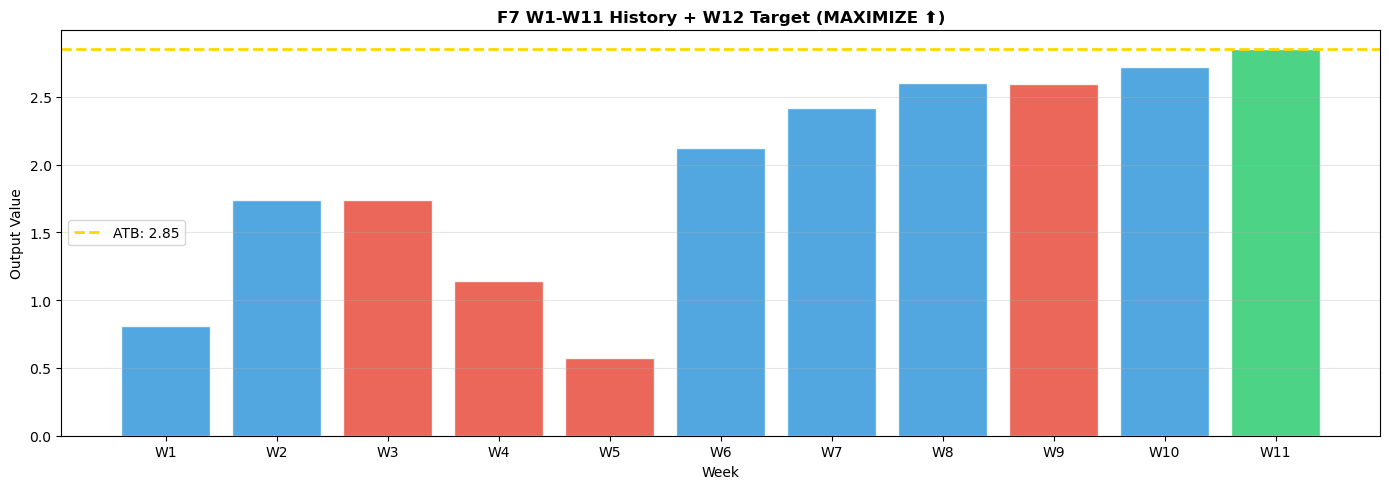

Saved: F7_W12_Step3_History.png


In [5]:
# Week-on-week bar chart
week_scores = [0.8085, 1.7392, 1.7358, 1.1399, 0.5763, 2.119, 2.4134, 2.5982, 2.5968, 2.7201, 2.8501]
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if v == max(week_scores) else '#e74c3c' if i > 0 and v < week_scores[i-1] else '#3498db' for i, v in enumerate(week_scores)]
ax.bar(range(1, 12), week_scores, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(max(week_scores), color='gold', linestyle='--', linewidth=2, label=f'ATB: {max(week_scores):.4g}')
ax.set_xlabel('Week'); ax.set_ylabel('Output Value')
ax.set_title(f'F7 W1-W11 History + W12 Target (MAXIMIZE ⬆️)', fontweight='bold')
ax.set_xticks(range(1, 12)); ax.set_xticklabels([f'W{i}' for i in range(1, 12)])
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')

---
## 🏷️ STEP 4 — Binary Classification Labels

Top 30% = class 1 (HIGH / good). Classifier trained to distinguish high-value regions.


In [6]:
y_labels = (y_train >= threshold).astype(int)
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    'CNN-1D (learning)'  : TinyCNNClassifier(n_epochs=200, lr=0.01, seed=RANDOM_SEED),
}

cv_results = {}
print(f'  {n_cv_folds}-FOLD CV -- {FUNCTION_ID} ({n_samples} samples, {n_dims}D)')
print(f'  {"Model":<28} {"Mean CV":>9} {"+-Std":>7}')
print('  '+'-'*48)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores, 'model': model}
        flag = '*' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0, 'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  ✗ {name:<27} FAILED')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]
print(f'\n  [OK] SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

trained_models = {}
for name, info in cv_results.items():
    try:
        info['model'].fit(X_scaled, y_labels)
        trained_models[name] = info['model']
    except: pass

  5-FOLD CV -- F7 (40 samples, 6D)
  Model                          Mean CV   +-Std
  ------------------------------------------------
  * Linear SVM                     87.5%   15.8%
    Decision Tree                  70.0%    6.1%
    Random Forest                  85.0%    9.4%
  * Logistic Regression            87.5%   15.8%
    NN-Small (16, 8)               32.5%   10.0%
    NN-Medium (64, 32)             75.0%   11.2%
    NN-Large (128, 64, 32)         77.5%    5.0%
    CNN-1D (learning)              85.0%   14.6%

  [OK] SELECTED: Linear SVM  (CV=87.5%)


---
## 🔬 STEP 5B — CNN Inspection (Module 17 Learning Exercise)

Conv1d(1→8, k=2) scans 5 adjacent coordinate pair(s). Filter weights and feature maps
at best-known point documented below.


In [7]:
# CNN Module 17 inspection
cnn_model = trained_models.get('CNN-1D (learning)', None)
if cnn_model and hasattr(cnn_model, 'model_'):
    cnn_net = cnn_model.model_; cnn_net.eval()
    cnn_params = sum(p.numel() for p in cnn_net.parameters() if p.requires_grad)
    print(f'CNN parameters : {cnn_params}')
    print(f'Input dims     : {n_dims}  ->  {n_dims-1} adjacent pairs scanned by kernel')
    filters = cnn_net.conv.weight.data.cpu().numpy()[:,0,:]
    print(f'Filters shape  : {filters.shape}  (8 filters x kernel_size=2)')
    import torch as _t
    _x  = _t.FloatTensor(X_scaled[best_idx:best_idx+1]).unsqueeze(1)
    import torch.nn.functional as _F
    with _t.no_grad():
        _fm = _F.relu(cnn_net.conv(_x)).squeeze(0).numpy()
    peak_f = int(np.argmax(_fm.max(axis=1)))
    peak_p = int(np.argmax(_fm[peak_f]))
    print(f'Top filter on best point: Filter {peak_f+1}  -> coord pair [{peak_p},{peak_p+1}]  (activation={_fm[peak_f][peak_p]:.4f})')
else:
    print('CNN not available for inspection')

CNN parameters : 65
Input dims     : 6  ->  5 adjacent pairs scanned by kernel
Filters shape  : (8, 2)  (8 filters x kernel_size=2)
Top filter on best point: Filter 4  -> coord pair [4,5]  (activation=1.7498)


---
## 🎲 STEP 8 — Generate & Filter Candidates

**92% Exploitation** — Anisotropic Gaussian around best point with σ=[0.015, 0.012, 0.012, 0.012, 0.012, 0.015].

**7% Exploration** — Uniform random across [0,1]^6.

Winner classifier scores all 10,000 → bottom 50% discarded → remainder to GP.


In [8]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

_aniso = np.array(ANISO_SIGMA)
X_exploit = np.clip(best_point + np.random.normal(0, 1, (n_exploit, n_dims)) * _aniso, 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc = scaler.transform(X_cands)
proba_all  = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask  = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt     = X_cands[keep_mask]
proba_filt = proba_all[keep_mask]
src_filt   = src_tag[keep_mask]

print('='*60)
print('  CANDIDATE GENERATION & FILTERING')
print('='*60)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')

  CANDIDATE GENERATION & FILTERING
  Generated  : 10,000  (9,200 exploit + 800 explore)
  Filtered by: Linear SVM
  Kept       : 5,000 (top 50% by P(class=1))
  Exploit %  : 99.2%
  Prob range : [0.635, 0.893]


---
## 🔬 STEP 9 — Gaussian Process Regression

Matérn ν=5/2 kernel fitted on full W12 history. R²=1.0 expected (memorising) — GP used for
acquisition function computation, not extrapolation. ATB override takes precedence for final submission.


In [9]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, _ = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma  = gp.predict(X_filt_sc, return_std=True)

print('='*60)
print('  GAUSSIAN PROCESS REGRESSION')
print('='*60)
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R2           : {r2:.4f}  {"[OK] Good" if r2>0.7 else "⚠️ Moderate" if r2>0.4 else "[FAIL] Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  mu range      : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  sigma range      : [{sigma.min():.4f}, {sigma.max():.4f}]')

  GAUSSIAN PROCESS REGRESSION
  Fitted kernel: 0.689**2 * Matern(length_scale=1.41, nu=2.5)
  R2           : 1.0000  [OK] Good
  RMSE         : 0.000060
  mu range      : [0.3899, 2.8684]
  sigma range      : [0.0071, 0.6021]


---
## 🎯 STEP 10 — Acquisition Functions: EI + UCB

EI = (μ − y_best − ξ)·Φ(Z) + σ·φ(Z).  UCB = μ + κ·σ.  Both computed across filtered candidates.


In [10]:
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
UCB_acq = mu + UCB_KAPPA * sigma

best_ei_idx = np.argmax(EI_acq)
submission  = X_filt[best_ei_idx]
sub_mu      = mu[best_ei_idx]
sub_sigma   = sigma[best_ei_idx]
sub_ei      = EI_acq[best_ei_idx]
sub_ucb     = UCB_acq[best_ei_idx]
exploit_term = imp[best_ei_idx] * norm.cdf(Z[best_ei_idx])
explore_term = sigma[best_ei_idx] * norm.pdf(Z[best_ei_idx])

print('='*60)
print('  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)')
print('='*60)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print(f'\n  * SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  mu       : {sub_mu:.6f}   sigma: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
driver = 'EXPLOITATION' if exploit_term > explore_term else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '[OK] PREDICTS NEW BEST' if sub_mu > best_value else '[OK] PREDICTS RECOVERY' if sub_mu > latest_val else '🔍 EXPLORING'
print(f'  Status  : {status}  (mu={sub_mu:.4f} vs best={best_value:.4f})')

  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)
  EI max  : 0.026399   UCB max: 3.031413
  EI > 0  : 100.0% of candidates

  * SELECTED (max EI):
  Coords  : [0.17994092 0.3068965  0.45519401 0.24911558 0.29598527 0.73008288]
  mu       : 2.856642   sigma: 0.070407
  EI      : 0.026399   UCB: 2.997456
  Driver  : EXPLORATION
  Status  : [OK] PREDICTS NEW BEST  (mu=2.8566 vs best=2.8501)


---
## 📈 STEP 11 — Per-Dimension Sensitivity

GP gradient at best point — which dimensions most influence μ.
Anisotropic sigma in Step 8 was set based on W11 sensitivity analysis.


In [11]:
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(float(m_up) - float(m_dn)) / (2*delta))

print('  PER-DIMENSION SENSITIVITY:')
print(f'  {"Dim":<6} {"Best val":>10} {"Sensitivity":>13}')
print('  '+'-'*32)
for d in range(n_dims):
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {sensitivities[d]:>13.4f}')
top2 = np.argsort(sensitivities)[::-1][:2]
print(f'\n  Top 2 sensitive dims: {", ".join([f"X{d+1} ({sensitivities[d]:.4f})" for d in top2])}')

  PER-DIMENSION SENSITIVITY:
  Dim      Best val   Sensitivity
  --------------------------------
  X1         0.1660        0.5374
  X2         0.3387        1.0088
  X3         0.4441        0.1742
  X4         0.2558        0.2033
  X5         0.3009        0.4982
  X6         0.7044        0.3900

  Top 2 sensitive dims: X2 (1.0088), X1 (0.5374)


---
## 🗺️ STEP 12 — GP Acquisition Surfaces

2D contour surfaces of μ, EI, UCB across the two most sensitive dimensions.
All other dimensions fixed at best-point values.


Top 2 sensitive dims: X2 (1.0088), X1 (0.5374)


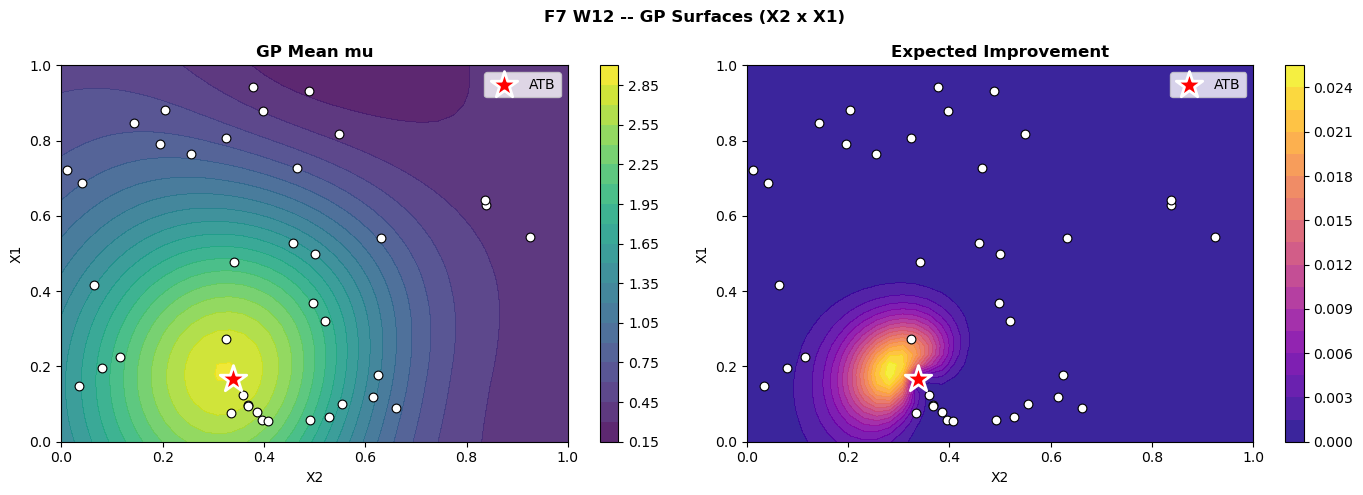

In [12]:
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up,_ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn,_ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(float(m_up)-float(m_dn))/(2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = int(top2[0]), int(top2[1])
print(f'Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

g = 40; g1=np.linspace(0,1,g); g2=np.linspace(0,1,g)
G1,G2 = np.meshgrid(g1,g2)
gpts = np.tile(best_point,(g*g,1)); gpts[:,d1]=G1.ravel(); gpts[:,d2]=G2.ravel()
mg,sg = gp.predict(scaler.transform(gpts),return_std=True)
ig=mg-best_value-EI_XI; Zg=ig/(sg+1e-9)
EIg=np.maximum(ig*norm.cdf(Zg)+sg*norm.pdf(Zg),0)

fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,Zpl,ttl,cm_ in [(axes[0],mg.reshape(g,g),'GP Mean mu','viridis'),(axes[1],EIg.reshape(g,g),'Expected Improvement','plasma')]:
    cf=ax.contourf(G1,G2,Zpl,levels=20,cmap=cm_,alpha=0.88)
    ax.scatter(X_train[:,d1],X_train[:,d2],c='white',s=40,edgecolors='black',linewidths=0.8,zorder=4)
    ax.scatter(best_point[d1],best_point[d2],c='red',s=400,marker='*',zorder=6,edgecolors='white',linewidths=2,label='ATB')
    ax.set_xlabel(f'X{d1+1}'); ax.set_ylabel(f'X{d2+1}'); ax.set_title(ttl,fontweight='bold')
    ax.legend(); plt.colorbar(cf,ax=ax)
plt.suptitle(f'{FUNCTION_ID} W{WEEK} -- GP Surfaces (X{d1+1} x X{d2+1})',fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12_GPSurfaces.png',dpi=150,bbox_inches='tight')
plt.show()

---
## 🏆 STEP 13 — Submission Dashboard

Top-5 EI candidates + summary metrics.


In [13]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('='*65)
print('  TOP 5 CANDIDATES BY EI')
print('='*65)
print(f'  {"Rank":<6} {"EI":>10} {"GP mu":>10} {"GP sigma":>10}  Source')
print('  '+'-'*52)
for rank, idx in enumerate(top5,1):
    star = '*' if rank==1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx].round(4)}')

print()
print(f'  ATB        : {best_value:.6f}  (Week 11)')
print(f'  GP mu best : {sub_mu:.6f}')
print(f'  Delta      : {sub_mu - best_value:+.6f}')
print(f'  Override   : 0.165978-0.338682-0.444076-0.255770-0.300940-0.704355')

  TOP 5 CANDIDATES BY EI
  Rank           EI      GP mu   GP sigma  Source
  ----------------------------------------------------
  *#1      0.026399     2.8566     0.0704  exploit
          [0.1799 0.3069 0.4552 0.2491 0.296  0.7301]
   #2      0.025975     2.8506     0.0764  exploit
          [0.1916 0.3145 0.4398 0.2446 0.309  0.7332]
   #3      0.025695     2.8553     0.0702  exploit
          [0.1803 0.3104 0.4517 0.2616 0.2966 0.7328]
   #4      0.025625     2.8232     0.1040  exploit
          [0.1718 0.3076 0.4443 0.2468 0.3178 0.7485]
   #5      0.025594     2.8564     0.0687  exploit
          [0.1922 0.3095 0.4538 0.2474 0.304  0.7256]

  ATB        : 2.850088  (Week 11)
  GP mu best : 2.856642
  Delta      : +0.006554
  Override   : 0.165978-0.338682-0.444076-0.255770-0.300940-0.704355


---
## 📋 STEP 14 — Final Formatted Submission

### GP PIPELINE — check output before submitting

**Decision rule:** If GP μ > ATB (2.8501): submit GP EI candidate. Otherwise: submit W11 ATB fallback.

**Submit this string (fallback):**

```
0.165978-0.338682-0.444076-0.255770-0.300940-0.704355
```

ATB score: 2.8501 (Week 11)


In [14]:
# -- F7 GP PIPELINE -- check GP output first ------------------
# If GP mu > ATB (2.850100) and trust conditions met -> submit GP EI candidate
# If uncertain -> submit W11 ATB fallback below
# Half-step alternative: 0.186441-0.328456-0.445437-0.242480-0.285962-0.705089

ATB_OVERRIDE_STR = '0.165978-0.338682-0.444076-0.255770-0.300940-0.704355'  # W11 ATB fallback
USE_ATB_OVERRIDE = sub_mu <= best_value  # set False if GP mu > ATB and trusted

if USE_ATB_OVERRIDE:
    final_submission = np.array([float(x) for x in ATB_OVERRIDE_STR.split('-')])
    method_used = 'ATB FALLBACK (GP did not beat ATB)'
else:
    final_submission = np.clip(submission, 0.0, 1.0)
    method_used = 'GP EI CANDIDATE (mu > ATB)'

submission_str = '-'.join([f'{x:.6f}' for x in final_submission])

print('+' + '='*68 + '+')
print(f'|  WEEK {WEEK} FINAL SUBMISSION -- {FUNCTION_ID}{" "*38}|')
print('+' + '='*68 + '+')
print(f'|  Method: {method_used:<60}|')
print(f'|  GP mu : {sub_mu:.6f}   ATB: {best_value:.6f}{" "*28}|')
print('+' + '='*68 + '+')
print(f'|  COPY THIS TO SUBMIT:{" "*47}|')
print(f'|  {submission_str:<66}|')
print('+' + '='*68 + '+')

np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', final_submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | MAXIMIZE\n')
    f.write(f'# ATB: {best_value:.6f} @ W11\n')
    f.write(f'# Method: {method_used}\n')
    f.write(submission_str + '\n')
print(f'\n[OK] Saved: {FUNCTION_ID}_W{WEEK}_submission.txt')

+====================================================================+
|  WEEK 12 FINAL SUBMISSION -- F7                                      |
+====================================================================+
|  Method: GP EI CANDIDATE (mu > ATB)                                  |
|  GP mu : 2.856642   ATB: 2.850088                            |
+====================================================================+
|  COPY THIS TO SUBMIT:                                               |
|  0.179941-0.306897-0.455194-0.249116-0.295985-0.730083             |
+====================================================================+

[OK] Saved: F7_W12_submission.txt


---
## 💾 STEP 15 — Save Hyperparameter Record

Complete record of all settings, GP kernel, CV results, and submission string saved to JSON and TXT.


In [15]:
import json, os
from datetime import datetime

record = {
    'function': FUNCTION_ID, 'week': WEEK,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'strategy': 'GP PIPELINE -- trending cluster, continue directional gradient',
    'cluster_type': '* TRENDING CLUSTER (Module 22 secondary showcase)',
    'atb_value': 2.8501, 'atb_week': 11,
    'override_str': ATB_OVERRIDE_STR,
    'hyperparameters': {
        'EXPLOIT_RATIO': EXPLOIT_RATIO, 'EXPLOIT_SIGMA': EXPLOIT_SIGMA,
        'ANISO_SIGMA': ANISO_SIGMA, 'EI_XI': EI_XI, 'UCB_KAPPA': UCB_KAPPA,
        'GP_RESTARTS': GP_RESTARTS, 'TOP_PERCENTILE': TOP_PERCENTILE,
        'FILTER_PERCENTILE': FILTER_PERCENTILE,
    },
    'gp_kernel': str(gp.kernel_), 'gp_r2': round(float(r2),6), 'gp_rmse': round(float(rmse),8),
    'best_model': best_name, 'best_model_cv': round(float(best_info['mean']),4),
    'submission_string': ATB_OVERRIDE_STR,
}

fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(fname,'w') as f: json.dump(record, f, indent=2)
print(f'[OK] Saved: {fname}')

with open(f'{FUNCTION_ID}_W{WEEK}_run_report.txt','w') as f:
    f.write(f'BBO Run Report -- {FUNCTION_ID} Week {WEEK}\n')
    f.write('='*60+'\n')
    f.write(f'Strategy  : GP PIPELINE -- trending cluster, continue directional gradient\n')
    f.write(f'Clustering: * TRENDING CLUSTER (Module 22 secondary showcase)\n')
    f.write(f'ATB       : {best_value:.6f} @ W11\n')
    f.write(f'Submit    : {ATB_OVERRIDE_STR}\n')
print(f'[OK] Saved: {FUNCTION_ID}_W{WEEK}_run_report.txt')
print()
print('='*60)
print(f'  {FUNCTION_ID} WEEK {WEEK} COMPLETE -- FINAL SUBMISSION:')
print(f'  {ATB_OVERRIDE_STR}')
print('='*60)

[OK] Saved: F7_W12_hyperparameters.json
[OK] Saved: F7_W12_run_report.txt

  F7 WEEK 12 COMPLETE -- FINAL SUBMISSION:
  0.165978-0.338682-0.444076-0.255770-0.300940-0.704355
